In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.layers import Input, Dense
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras import layers, Model

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.layers import LeakyReLU


In [2]:

data=pd.read_excel("data - copie.xlsx")
data.columns=['p','v','h','t','Ra','density','VED','LED','PED']
data.head(10)
X=data[['VED']].values
y=data[['Ra']].values

In [3]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5



In [10]:

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_train_bc=box_cox_fun(y_train)

rf = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train_bc)

y_pred_rf_bc = rf.predict(X_test)
y_pred_rf=inverse_box_cox(y_pred_rf_bc)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")



c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R2: -0.7248
RMSE: 5.4046
MAE: 4.1274


In [ ]:



def rmse_function(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

model = Sequential()


model.add(Dense(64, input_dim=X_train.shape[1], activation=None)) 
model.add(BatchNormalization())  
model.add(LeakyReLU(alpha=0.1))  

model.add(Dense(32, activation=None))
model.add(BatchNormalization())  
model.add(LeakyReLU(alpha=0.1)) 
model.add(Dropout(0.2)) 


model.add(Dense(1, activation='linear'))

model.compile(optimizer=SGD(), loss=rmse_function, metrics=['mae'])

model.fit(X_train, y_train_bc, epochs=2000, batch_size=8, validation_data=(X_test, y_test))

loss, mae = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, MAE: {mae}')

y_predict_bc = model.predict(X_test)
y_predict=inverse_box_cox(y_predict_bc)

rmse = np.sqrt(mean_squared_error(y_test, y_predict))
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)


print(f"R2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Epoch 1/2000


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.6741 - mae: 8.7167 - val_loss: 10.1235 - val_mae: 9.3302
Epoch 2/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.8604 - mae: 8.7176 - val_loss: 9.8312 - val_mae: 9.0126
Epoch 3/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1094 - mae: 7.6695 - val_loss: 9.5216 - val_mae: 8.6753
Epoch 4/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7950 - mae: 7.2627 - val_loss: 9.1629 - val_mae: 8.2829
Epoch 5/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3254 - mae: 6.7455 - val_loss: 8.7552 - val_mae: 7.8334
Epoch 6/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.5674 - mae: 5.2334 - val_loss: 8.2147 - val_mae: 7.2310
Epoch 7/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3054 - mae: 4.7465 - val_loss: 7.6154 - val_mae: 6.5899
Epoch 8/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.8567 - mae: 4.3606 - val_loss: 6.9796 - val_mae: 5.9090
Epoch 9/2000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8025 

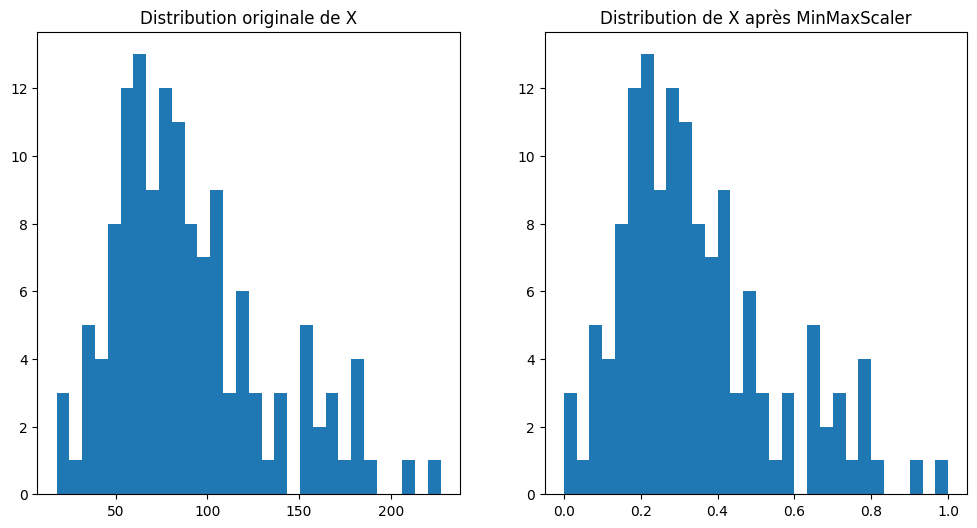

In [38]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(X, bins=30)
plt.title('Distribution originale de X')

plt.subplot(1, 2, 2)
plt.hist(X_scaled, bins=30)
plt.title('Distribution de X après MinMaxScaler')

plt.show()


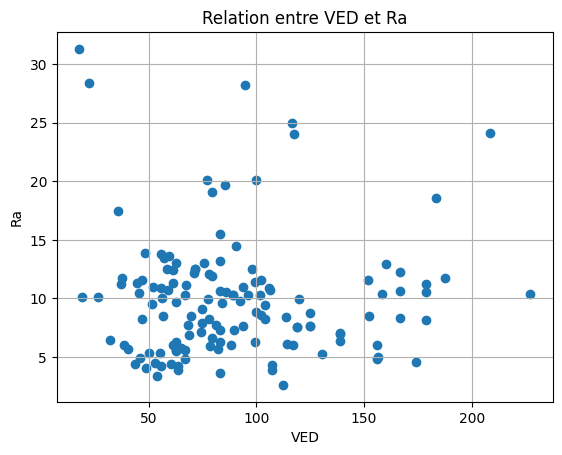

In [28]:

plt.scatter(data["VED"], data["Ra"])
plt.xlabel("VED")
plt.ylabel("Ra")
plt.title("Relation entre VED et Ra")
plt.grid(True)
plt.show()


In [36]:

scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

def create_autoencoder(latent_dim):
    input_dim = X_scaled.shape[1]  
    
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(32, activation='relu')(input_layer)
    encoded = Dense(16, activation='relu')(encoded)
    latent = Dense(latent_dim, activation='relu')(encoded)
    decoded = Dense(16, activation='relu')(latent)
    decoded = Dense(32, activation='relu')(decoded)

    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    
    autoencoder = Model(input_layer, output_layer)
    encoder = Model(input_layer, latent)
    
    autoencoder.compile(optimizer='adam', loss='mae')
    
    return autoencoder, encoder


latent_dims = [2, 4, 6, 8, 10, 12, 14, 16, 20, 25, 32]


encoders = {}

for latent_dim in latent_dims:
   
    autoencoder, encoder = create_autoencoder(latent_dim)
    autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=4, shuffle=True, validation_split=0.2)
    
 
    encoders[latent_dim] = encoder


Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2098 - val_loss: 0.2547
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1986 - val_loss: 0.2176
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1636 - val_loss: 0.1932
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1560 - val_loss: 0.1674
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1453 - val_loss: 0.1402
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1124 - val_loss: 0.1114
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0753 - val_loss: 0.0646
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0267 - val_loss: 0.0461
Epoch 9/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0204 - val_loss: 0.0432
Epoch 10/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0171 - val_loss: 0.0404
Epoch 11/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173 - val_loss: 0.0408
Epoch 12/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

In [37]:


def evaluate_rf(encoder, X_scaled, y):
    X_latent = encoder.predict(X_scaled) 
    X_train, X_test, y_train, y_test = train_test_split(X_latent, y, test_size=0.2, random_state=42)
    y_train_bc=box_cox_fun(y_train)
    rf = RandomForestRegressor(n_estimators=300)
    rf.fit(X_train, y_train_bc.ravel())
    y_pred_pc = rf.predict(X_test)
    y_pred=inverse_box_cox(y_pred_pc)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return rmse, r2

performances = {}

for latent_dim, encoder in encoders.items():
    rmse, r2 = evaluate_rf(encoder, X_scaled, y)
    performances[latent_dim] = {'RMSE': rmse, 'R2': r2}

for latent_dim, metrics in performances.items():
    print(f"Latent Dim: {latent_dim} -> RMSE: {metrics['RMSE']:.4f}, R2: {metrics['R2']:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Latent Dim: 2 -> RMSE: 5.6385, R2: -0.8773
Latent Dim: 4 -> RMSE: 5.6299, R2: -0.8717
Latent Dim: 6 -> RMSE: 5.2875, R2: -0.6509
Latent Dim: 8 -> RMSE: 5.7552, R2: -0.9559
Latent Dim: 10 -> RMSE: 5.5850, R2: -0.8419
Latent Dim: 12 -> RMSE: 5.5911, R2: -0.8459
Latent Dim: 14 -> RMSE: 5.6840, R2: -0.9078
Latent Dim: 16 -> RMSE: 5.6333, R2: -0.8739
Latent Dim: 20 -> RMSE: 5.3979, R2: -0.7206
Latent Dim: 25 -> RMSE: 5.5209, R2: -0.7999
Latent Dim: 32 -> RMSE: 5.5628, R2: -0.8273


In [ ]:
from catboost import CatBoostRegressor
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
def evaluate_xgb(encoder, X_scaled, y):
    X_latent = encoder.predict(X_scaled) 
    X_train, X_test, y_train, y_test = train_test_split(X_latent, y, test_size=0.2, random_state=42)
    y_train_bc=box_cox_fun(y_train)
    cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',verbose=0)
    cat_model.fit(X_train, y_train_bc.ravel())
    y_pred_pc = cat_model.predict(X_test)
    y_pred=inverse_box_cox(y_pred_pc)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return rmse, r2

performances = {}

for latent_dim, encoder in encoders.items():
    rmse, r2 = evaluate_xgb(encoder, X_scaled, y)
    performances[latent_dim] = {'RMSE': rmse, 'R2': r2}

for latent_dim, metrics in performances.items():
    print(f"Latent Dim: {latent_dim} -> RMSE: {metrics['RMSE']:.4f}, R2: {metrics['R2']:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Latent Dim: 2 -> RMSE: 6.5282, R2: -1.5166
Latent Dim: 4 -> RMSE: 6.4948, R2: -1.4909
Latent Dim: 6 -> RMSE: 6.4819, R2: -1.4810
Latent Dim: 8 -> RMSE: 6.3181, R2: -1.3572
Latent Dim: 10 -> RMSE: 6.3847, R2: -1.4072
Latent Dim: 12 -> RMSE: 6.3330, R2: -1.3683
Latent Dim: 14 -> RMSE: 6.4189, R2: -1.4330
Latent Dim: 16 -> RMSE: 6.3263, R2: -1.3633
Latent Dim: 20 -> RMSE: 6.5283, R2: -1.5166
Latent Dim: 25 -> RMSE: 6.1351, R2: -1.2226
Latent Dim: 32 -> RMSE: 6.2612, R2: -1.3149
